# Feature Importance in sklearn — Random Forest on MNIST Digits
After training a Random Forest, each feature (pixel) gets an **importance score** that says how useful it was for making predictions.

### Key idea
- Pixel importance = how often that pixel appeared in splits, weighted by how much it reduced impurity
- When visualised as a heatmap, the important pixels form the shape of the digits — the model learned which regions matter


## Step 1: Imports

In [10]:
import pandas as pd
import seaborn as sns

## Step 2: Load MNIST Dataset
`train.csv` is the Kaggle digit recogniser format:
- First column = `label` (digit 0–9)
- Remaining 64 columns = pixel values (8×8 image flattened)


In [11]:
df = pd.read_csv(r'd:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\100-days-of-machine-learning-main\day59-classification-metrics\train.csv')

In [12]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
0,0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


## Step 3: Prepare Features and Target
- `X` = pixel columns (all except first)
- `y` = label column (first column)


In [13]:
X = df.iloc[:,1:]
y = df.iloc[:,0]


## Step 4: Visualise One Training Sample
Reshape the 64 pixel values back into a 8×8 grid to see what the digit looks like.
`X.iloc[5]` = the 6th training image.


<Axes: >

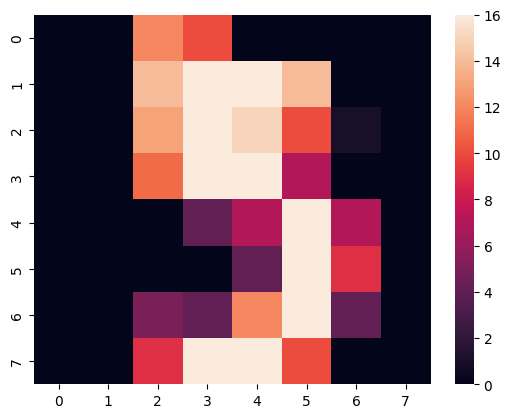

In [14]:
sns.heatmap(X.iloc[5].values.reshape(8,8))

## Step 5: Train Random Forest
Default `n_estimators=100`. Training on all 64 pixel features across all samples.
This may take a minute — the model is learning which pixels matter for distinguishing digits.


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Step 6: Extract Feature Importances
`rf.feature_importances_` returns an array of 784 values — one per pixel.
- Higher value = that pixel was more useful for splitting (more discriminative)
- Values sum to 1.0


In [16]:
rf.feature_importances_

array([0.00000000e+00, 2.18856098e-03, 2.07422501e-02, 9.57695516e-03,
       8.81503171e-03, 1.87509528e-02, 7.89656324e-03, 1.31642250e-03,
       9.14070161e-05, 1.14812266e-02, 2.52711429e-02, 6.95511497e-03,
       1.61203306e-02, 3.09315568e-02, 5.65287175e-03, 5.74350375e-04,
       4.95832851e-05, 6.31720432e-03, 2.14639893e-02, 2.62895069e-02,
       2.68633192e-02, 4.78998127e-02, 8.57380502e-03, 7.95051150e-05,
       4.52267797e-05, 1.57313729e-02, 4.39202190e-02, 2.57267903e-02,
       3.42936313e-02, 2.54232755e-02, 3.25349995e-02, 0.00000000e+00,
       0.00000000e+00, 2.77368422e-02, 2.51072674e-02, 1.73852157e-02,
       3.68230954e-02, 2.04357931e-02, 2.50276039e-02, 0.00000000e+00,
       2.37657058e-05, 1.10536707e-02, 4.07211625e-02, 4.60549962e-02,
       1.96175429e-02, 1.76581564e-02, 1.74718537e-02, 2.93044826e-05,
       1.17740154e-05, 1.91281957e-03, 1.70881330e-02, 2.09668188e-02,
       1.41000354e-02, 2.32881627e-02, 2.61012255e-02, 1.93404047e-03,
      

In [17]:
rf.feature_importances_.shape

(64,)

## Step 7: Visualise Feature Importances as a Heatmap
Reshape the 64 importance values back to 8×8 and plot as a heatmap.

**What to expect:** Bright regions = important pixels (centre/edges of digits).
Dark regions = unimportant pixels (corners, background).
The pattern reveals *where in the image* the model looks to distinguish digits.


<Axes: >

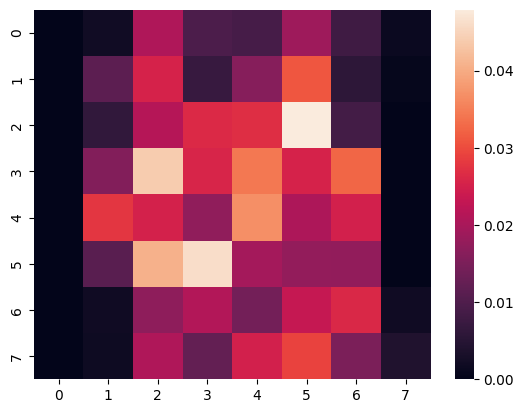

In [18]:
sns.heatmap(rf.feature_importances_.reshape(8,8))